## Import Packages

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Softmax
from tensorflow.keras import optimizers
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## PL Data From csv

In [2]:
data = pd.read_csv("PL_data.csv",sep=";")
x = data[['Headcount', 'Mean', 'Median', 'Gini',
       'Population.Density',
       'Urban.Pop', 'Age.Dependency']]
y = data[['Poverty.Line.Month']]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)

In [3]:
x

,Headcount,Mean,Median,Gini,Population.Density,Urban.Pop,Age.Dependency
0,36.600000,110.173103,79.398300,42.715511,17.402450,58.282,97.840785
1,32.300001,92.686470,57.831089,51.272112,24.713052,65.514,96.175740
2,14.300001,239.770493,207.602493,28.960481,105.854051,54.330,47.033080
3,23.400000,261.816986,214.909698,33.171090,104.870693,59.383,45.682097
4,30.300000,604.838013,456.542694,42.032531,15.928135,91.627,56.102271
...,...,...,...,...,...,...,...
477,77.999997,104.721100,67.434868,48.333681,12.563705,36.638,97.073709
478,62.800002,77.538948,42.403179,54.617512,16.375676,37.395,97.522386
479,60.500002,75.441406,39.152908,55.621493,18.302619,39.355,97.517656
480,54.400003,87.163300,45.457970,57.136059,21.360741,41.907,93.203995


## Data normalization

In [4]:
mean = x_train.mean()
std  = x_train.std()
x_train = (x_train - mean) / std
x_test  = (x_test  - mean) / std

x_train, y_train = np.array(x_train), np.array(y_train)
x_test,  y_test  = np.array(x_test),  np.array(y_test)

## Model

In [5]:
model = Sequential()
#Input Layer
model.add(Dense(x_train.shape[1], activation='relu', input_dim = x_train.shape[1]))
#Hidden Layer
model.add(Dense(32,kernel_initializer='normal', activation='relu'))
model.add(Dense(64,kernel_initializer='normal', activation='relu'))
model.add(Dense(32,kernel_initializer='normal', activation='relu'))
#Output Layer
model.add(Dense(1,kernel_initializer='normal', activation = 'relu'))  

#Compile the network 
model.compile(loss='mse', optimizer='adam', metrics=['mse','mae'])

## Train the model

In [6]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 7)                 56        
_________________________________________________________________
dense_1 (Dense)              (None, 32)                256       
_________________________________________________________________
dense_2 (Dense)              (None, 64)                2112      
_________________________________________________________________
dense_3 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 33        
Total params: 4,537
Trainable params: 4,537
Non-trainable params: 0
_________________________________________________________________


In [7]:
history = model.fit(x_train,
                    y_train,
                    epochs          = 150,
                    batch_size      = 20,
                    verbose         = 1,
                    validation_data = (x_test, y_test))

Epoch 1/150
20/20 [==============================] - 1s 41ms/step - loss: 81359.9433 - mse: 81359.9433 - mae: 194.1353 - val_loss: 87630.8828 - val_mse: 87630.8828 - val_mae: 217.8186
Epoch 2/150
20/20 [==============================] - 0s 3ms/step - loss: 85137.2098 - mse: 85137.2098 - mae: 198.9008 - val_loss: 87298.8750 - val_mse: 87298.8750 - val_mae: 217.0773
Epoch 3/150
20/20 [==============================] - 0s 3ms/step - loss: 97976.7191 - mse: 97976.7180 - mae: 212.3775 - val_loss: 85320.1406 - val_mse: 85320.1406 - val_mae: 212.8525
Epoch 4/150
20/20 [==============================] - 0s 3ms/step - loss: 77207.6408 - mse: 77207.6408 - mae: 182.3041 - val_loss: 76825.3203 - val_mse: 76825.3281 - val_mae: 195.0004
Epoch 5/150
20/20 [==============================] - 0s 3ms/step - loss: 79852.0846 - mse: 79852.0846 - mae: 176.9133 - val_loss: 54320.9844 - val_mse: 54320.9844 - val_mae: 146.7684
Epoch 6/150
20/20 [==============================] - 0s 3ms/step - loss: 47837.9862 

Epoch 47/150
20/20 [==============================] - 0s 2ms/step - loss: 2420.5568 - mse: 2420.5568 - mae: 35.6838 - val_loss: 2580.3369 - val_mse: 2580.3374 - val_mae: 38.6624
Epoch 48/150
20/20 [==============================] - 0s 3ms/step - loss: 2378.2457 - mse: 2378.2457 - mae: 34.6034 - val_loss: 2564.1152 - val_mse: 2564.1152 - val_mae: 38.3752
Epoch 49/150
20/20 [==============================] - 0s 2ms/step - loss: 2240.5816 - mse: 2240.5816 - mae: 34.4065 - val_loss: 2548.4993 - val_mse: 2548.4993 - val_mae: 38.4171
Epoch 50/150
20/20 [==============================] - 0s 2ms/step - loss: 2744.1514 - mse: 2744.1514 - mae: 36.2864 - val_loss: 2536.3184 - val_mse: 2536.3184 - val_mae: 37.9751
Epoch 51/150
20/20 [==============================] - 0s 2ms/step - loss: 2040.3396 - mse: 2040.3396 - mae: 32.7901 - val_loss: 2477.8560 - val_mse: 2477.8560 - val_mae: 38.0344
Epoch 52/150
20/20 [==============================] - 0s 3ms/step - loss: 2565.9479 - mse: 2565.9479 - mae: 35

20/20 [==============================] - 0s 2ms/step - loss: 2172.0115 - mse: 2172.0115 - mae: 32.3187 - val_loss: 1870.7031 - val_mse: 1870.7031 - val_mae: 32.1044
Epoch 94/150
20/20 [==============================] - 0s 2ms/step - loss: 1876.9597 - mse: 1876.9596 - mae: 31.5081 - val_loss: 1860.9794 - val_mse: 1860.9794 - val_mae: 32.0383
Epoch 95/150
20/20 [==============================] - 0s 2ms/step - loss: 1703.7027 - mse: 1703.7027 - mae: 28.8232 - val_loss: 1838.5842 - val_mse: 1838.5844 - val_mae: 32.1398
Epoch 96/150
20/20 [==============================] - 0s 2ms/step - loss: 2157.8496 - mse: 2157.8496 - mae: 31.7938 - val_loss: 1885.6322 - val_mse: 1885.6322 - val_mae: 31.7563
Epoch 97/150
20/20 [==============================] - 0s 2ms/step - loss: 2008.6820 - mse: 2008.6821 - mae: 30.2492 - val_loss: 1820.0273 - val_mse: 1820.0271 - val_mae: 32.2191
Epoch 98/150
20/20 [==============================] - 0s 2ms/step - loss: 2101.5811 - mse: 2101.5811 - mae: 31.9561 - val_l

Epoch 139/150
20/20 [==============================] - 0s 2ms/step - loss: 1617.2815 - mse: 1617.2815 - mae: 27.2714 - val_loss: 1416.8444 - val_mse: 1416.8444 - val_mae: 27.8264
Epoch 140/150
20/20 [==============================] - 0s 2ms/step - loss: 1828.0180 - mse: 1828.0180 - mae: 29.1658 - val_loss: 1494.3881 - val_mse: 1494.3881 - val_mae: 27.5054
Epoch 141/150
20/20 [==============================] - 0s 3ms/step - loss: 1493.8309 - mse: 1493.8309 - mae: 26.3964 - val_loss: 1478.3383 - val_mse: 1478.3383 - val_mae: 29.0477
Epoch 142/150
20/20 [==============================] - 0s 2ms/step - loss: 1530.3653 - mse: 1530.3653 - mae: 28.2168 - val_loss: 1426.2928 - val_mse: 1426.2928 - val_mae: 27.2505
Epoch 143/150
20/20 [==============================] - 0s 2ms/step - loss: 1456.7172 - mse: 1456.7172 - mae: 26.1326 - val_loss: 1374.5430 - val_mse: 1374.5430 - val_mae: 27.0902
Epoch 144/150
20/20 [==============================] - 0s 2ms/step - loss: 1424.2780 - mse: 1424.2780 - m

## Evaluate Model

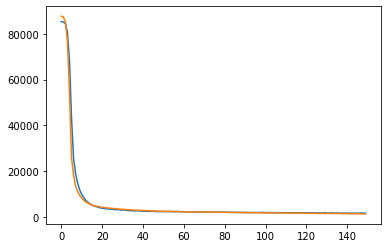

In [8]:
plt.plot(history.history['mse'])
plt.plot(history.history['val_mse'])

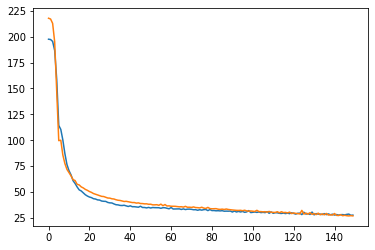

In [9]:
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])

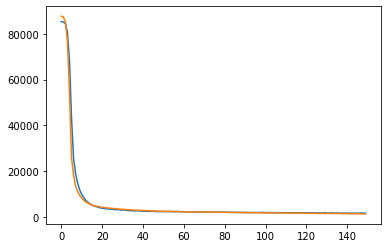

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

## Prediction

In [17]:
my_data = [ -1.07 ,  1.02 , 0.98,  -0.41, -0.48, 0.69, -0.64 ]
real_PL = 337.29
my_data=np.array(my_data).reshape(1,7)

In [19]:
predictions = model.predict( my_data )
print("Prediction : {:.2f} K$".format(predictions[0][0]))
print("Reality    : {:.2f} K$".format(real_PL))

Prediction : 336.03 K$
Reality    : 337.29 K$
